In [5]:
import pandas as pd

df = pd.read_csv("../data/netflix.csv", sep="|")
df.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [7]:
df.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [9]:
## Dataset Shape

In [11]:
df.shape

(943, 5)

In [13]:
## Column Info

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 943 entries, 0 to 942
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     943 non-null    int64 
 1   age         943 non-null    int64 
 2   gender      943 non-null    object
 3   occupation  943 non-null    object
 4   zip_code    943 non-null    object
dtypes: int64(2), object(3)
memory usage: 37.0+ KB


In [17]:
## Basic Statistics

In [19]:
df.describe()

,user_id,age
count,943.000000,943.000000
mean,472.000000,34.051962
std,272.364951,12.192740
min,1.000000,7.000000
25%,236.500000,25.000000
50%,472.000000,31.000000
75%,707.500000,43.000000
max,943.000000,73.000000


In [21]:
## Data Types + Real Data Understanding

In [23]:
## Check Data Types

In [25]:
df.dtypes

user_id        int64
age            int64
gender        object
occupation    object
zip_code      object
dtype: object

In [27]:
## Identify Column Types (REAL THINKING)

In [29]:
## Count Unique Values

In [31]:
df["occupation"].value_counts()

occupation
student          196
other            105
educator          95
administrator     79
engineer          67
programmer        66
librarian         51
writer            45
executive         32
scientist         31
artist            28
technician        27
marketing         26
entertainment     18
healthcare        16
retired           14
lawyer            12
salesman          12
none               9
homemaker          7
doctor             7
Name: count, dtype: int64

In [33]:
## Gender Distribution

In [35]:
df["gender"].value_counts()

gender
M    670
F    273
Name: count, dtype: int64

In [37]:
##Data Filtering (Real Analysis Starts)

In [39]:
## Filter Users Above Age 30

In [41]:
df[df["age"] > 30]

,user_id,age,gender,occupation,zip_code
1,2,53,F,other,94043
4,5,33,F,other,15213
5,6,42,M,executive,98101
6,7,57,M,administrator,91344
7,8,36,M,administrator,05201
...,...,...,...,...,...
934,935,42,M,doctor,66221
936,937,48,M,educator,98072
937,938,38,F,technician,55038
939,940,32,M,administrator,02215


In [43]:
## Filter Only Males

In [45]:
df[df["gender"] == "M"]

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
2,3,23,M,writer,32067
3,4,24,M,technician,43537
5,6,42,M,executive,98101
6,7,57,M,administrator,91344
...,...,...,...,...,...
935,936,24,M,other,32789
936,937,48,M,educator,98072
939,940,32,M,administrator,02215
940,941,20,M,student,97229


In [47]:
## Filter Technicians

In [49]:
df[df["occupation"] == "technician"]

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
3,4,24,M,technician,43537
43,44,26,M,technician,46260
76,77,30,M,technician,29379
142,143,42,M,technician,08832
196,197,55,M,technician,75094
243,244,28,M,technician,80525
293,294,34,M,technician,92110
310,311,32,M,technician,73071
324,325,48,M,technician,02139


In [51]:
## COMBINED FILTER (IMPORTANT)

In [53]:
## Male users above 30

In [55]:
df[(df["age"] > 30) & (df["gender"] == "M")]

,user_id,age,gender,occupation,zip_code
5,6,42,M,executive,98101
6,7,57,M,administrator,91344
7,8,36,M,administrator,05201
9,10,53,M,lawyer,90703
12,13,47,M,educator,29206
...,...,...,...,...,...
931,932,58,M,educator,06437
933,934,61,M,engineer,22902
934,935,42,M,doctor,66221
936,937,48,M,educator,98072


In [57]:
## GroupBy (Real Business Insights)

In [59]:
## Average Age by Gender

In [61]:
df.groupby("gender")["age"].mean()

gender
F    33.813187
M    34.149254
Name: age, dtype: float64

In [63]:
## Count Users by Occupation

In [65]:
df.groupby("occupation")["user_id"].count().sort_values(ascending=False)

occupation
student          196
other            105
educator          95
administrator     79
engineer          67
programmer        66
librarian         51
writer            45
executive         32
scientist         31
artist            28
technician        27
marketing         26
entertainment     18
healthcare        16
retired           14
lawyer            12
salesman          12
none               9
homemaker          7
doctor             7
Name: user_id, dtype: int64

In [67]:
## Average Age by Occupation

In [69]:
df.groupby("occupation")["age"].mean().sort_values(ascending=False)

occupation
retired          63.071429
doctor           43.571429
educator         42.010526
healthcare       41.562500
librarian        40.000000
administrator    38.746835
executive        38.718750
marketing        37.615385
lawyer           36.750000
engineer         36.388060
writer           36.311111
salesman         35.666667
scientist        35.548387
other            34.523810
technician       33.148148
programmer       33.121212
homemaker        32.571429
artist           31.392857
entertainment    29.222222
none             26.555556
student          22.081633
Name: age, dtype: float64

In [71]:
## Import Matplotlib

In [73]:
import matplotlib.pyplot as plt

In [75]:
## Bar Chart (Gender vs Average Age)

In [77]:
gender_age = df.groupby("gender")["age"].mean()

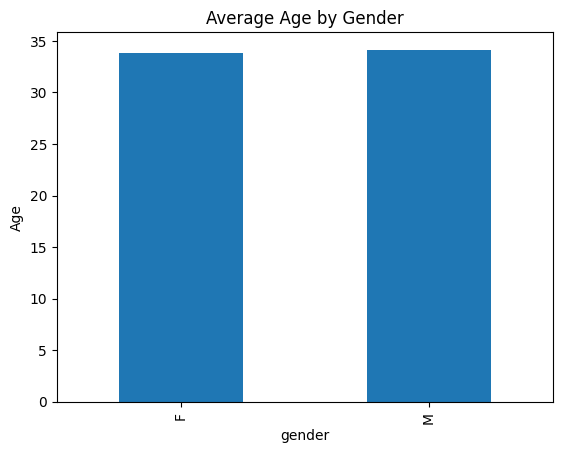

In [79]:
gender_age.plot(kind="bar")
plt.title("Average Age by Gender")
plt.ylabel("Age")
plt.show()

In [81]:
## Bar Chart (Occupation Count)

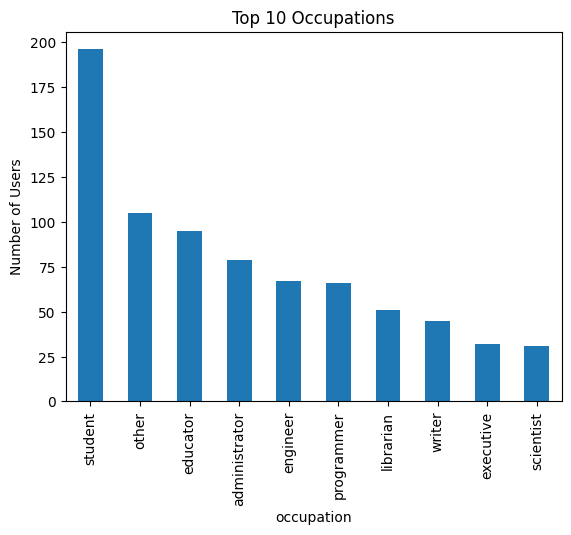

In [83]:
occupation_count = df["occupation"].value_counts().head(10)

occupation_count.plot(kind="bar")
plt.title("Top 10 Occupations")
plt.ylabel("Number of Users")
plt.show()

In [85]:
## Seaborn (Professional Data Visualization)

In [87]:
## Import Seaborn

In [89]:
import seaborn as sns
import matplotlib.pyplot as plt

In [91]:
## Count Plot (Gender Distribution)

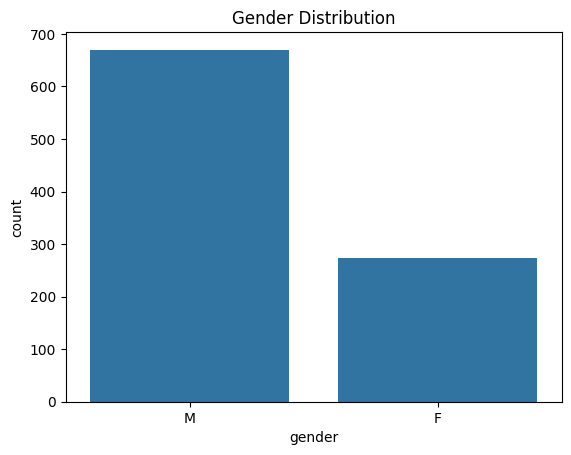

In [93]:
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

In [95]:
## Count Plot (Top Occupations)

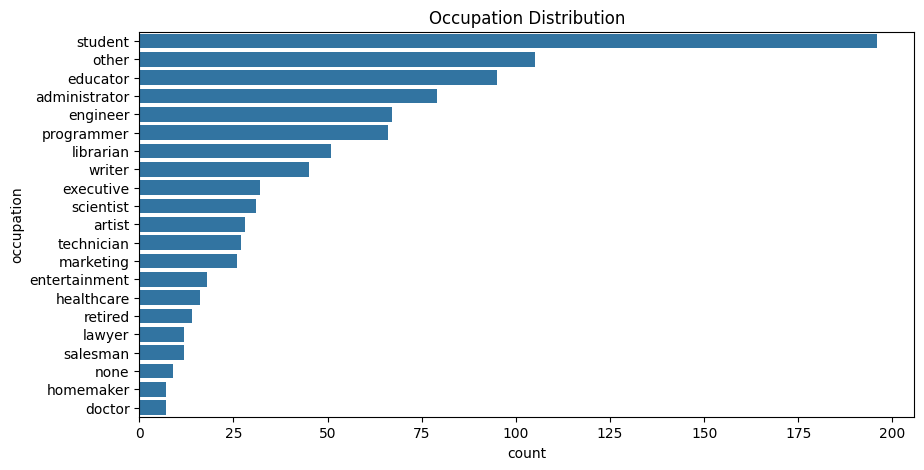

In [97]:
plt.figure(figsize=(10,5))
sns.countplot(y="occupation", data=df, order=df["occupation"].value_counts().index)
plt.title("Occupation Distribution")
plt.show()

In [99]:
## Boxplot (Age by Gender)

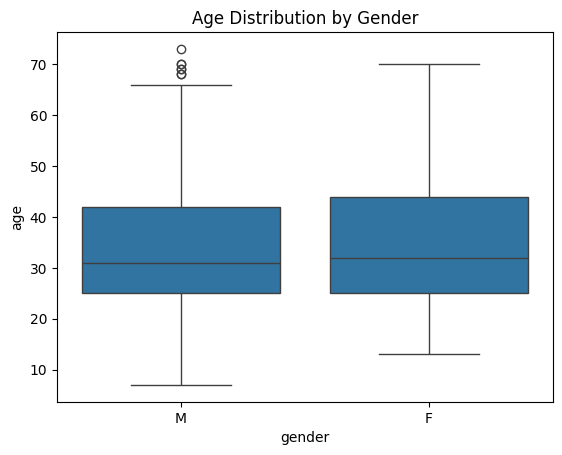

In [101]:
sns.boxplot(x="gender", y="age", data=df)
plt.title("Age Distribution by Gender")
plt.show()

# STEP 10 — Real EDA Project Summary

## Project Overview

This project explores a user demographics dataset containing information about 943 users. The analysis focuses on understanding user characteristics through age, gender, and occupation data. The goal was to identify demographic patterns and generate insights using Python, Pandas, Matplotlib, and Seaborn.

---

## Dataset Summary

* Total Records: 943 users
* Total Features: 5
* Numerical Variables:

  * user_id
  * age
* Categorical Variables:

  * gender
  * occupation
  * zip_code

The dataset was complete and contained no missing values, making it suitable for analysis without additional cleaning.

---

## Key Findings

### 1. Gender Distribution

The dataset contains:

* 670 Male users
* 273 Female users

Male users represent approximately 71% of the dataset, while female users account for approximately 29%.

### 2. Average User Age

The average age of users is approximately 34 years.

Most users fall between 25 and 43 years old, based on the quartile analysis.

### 3. Average Age by Gender

Average age by gender:

* Male: 34.15 years
* Female: 33.81 years

The average age is very similar across both genders, indicating no significant age difference between male and female users.

### 4. Occupation Analysis

Students represent the largest occupation group with 196 users.

Other highly represented occupations include:

* Other
* Educator
* Administrator
* Engineer
* Programmer

This suggests the dataset contains a large number of users from educational and technical backgrounds.

### 5. Age by Occupation

The occupation with the highest average age is:

* Retired: 63.07 years

The occupation with the lowest average age is:

* Student: 22.08 years

This result aligns with expected demographic patterns and validates the quality of the dataset.

### 6. Filtering Analysis

Filtering operations revealed:

* A significant number of users are older than 30 years.
* Male users make up the majority of users over age 30.
* Technicians represent a relatively small but clearly identifiable user segment.

---

## Visual Analysis

The visualizations provided several important insights:

### Gender Distribution Chart

The gender count plot clearly shows a higher proportion of male users.

### Occupation Distribution Chart

The occupation distribution reveals that students dominate the dataset, followed by educators and administrators.

### Average Age by Gender Chart

The average age bar chart confirms that male and female users have nearly identical average ages.

### Age Distribution by Gender

The boxplot shows that both genders have a similar age spread and distribution.

---

## Business Insights

Based on the analysis:

* Students are the primary user segment and may require targeted products, services, or recommendations.
* Educational and technical occupations represent a large portion of the user base.
* User age and occupation can be valuable features for customer segmentation.
* Demographic information can support recommendation systems and personalized user experiences.

---

## Conclusion

This exploratory data analysis successfully examined demographic patterns across 943 users. The project identified trends related to gender distribution, occupation frequency, and age characteristics.

Through data inspection, filtering, aggregation, and visualization, meaningful insights were generated from the dataset. The project demonstrates practical skills in data exploration, statistical analysis, data visualization, and business insight generation using Python.


# Author

Kamal Kenzi 

# Tools Used

- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook
- VS Code

# Skills Demonstrated

- Data Cleaning
- Data Exploration
- Data Filtering
- GroupBy Analysis
- Data Visualization
- Business Insight Generation